<a href="https://colab.research.google.com/github/MeenakshiRajpurohit/CMPE-255-Data-Mining/blob/main/Ensemble_Learning_and_Random_Forests.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**Ensemble Learning and Random Forests**

# Setup

This project requires Python 3.7 or above:

In [1]:
import sys

assert sys.version_info >= (3, 7)

It also requires Scikit-Learn ≥ 1.0.1:

In [2]:
from packaging import version
import sklearn

assert version.parse(sklearn.__version__) >= version.parse("1.0.1")

As we did in previous chapters, let's define the default font sizes to make the figures prettier:

In [3]:
import matplotlib.pyplot as plt

plt.rc('font', size=14)
plt.rc('axes', labelsize=14, titlesize=14)
plt.rc('legend', fontsize=14)
plt.rc('xtick', labelsize=10)
plt.rc('ytick', labelsize=10)

And let's create the `images/ensembles` folder (if it doesn't already exist), and define the `save_fig()` function which is used through this notebook to save the figures in high-res for the book:

In [5]:
import numpy as np
from sklearn.datasets import fetch_openml, load_iris
from sklearn.ensemble import (
    RandomForestClassifier,
    ExtraTreesClassifier,
    VotingClassifier,
    StackingClassifier,
)
from sklearn.svm import LinearSVC
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import accuracy_score
from sklearn.preprocessing import LabelEncoder

## Feature Importance

In [6]:
from sklearn.datasets import load_iris

iris = load_iris(as_frame=True)
rnd_clf = RandomForestClassifier(n_estimators=500, random_state=42)
rnd_clf.fit(iris.data, iris.target)
for score, name in zip(rnd_clf.feature_importances_, iris.data.columns):
    print(round(score, 2), name)

0.11 sepal length (cm)
0.02 sepal width (cm)
0.44 petal length (cm)
0.42 petal width (cm)


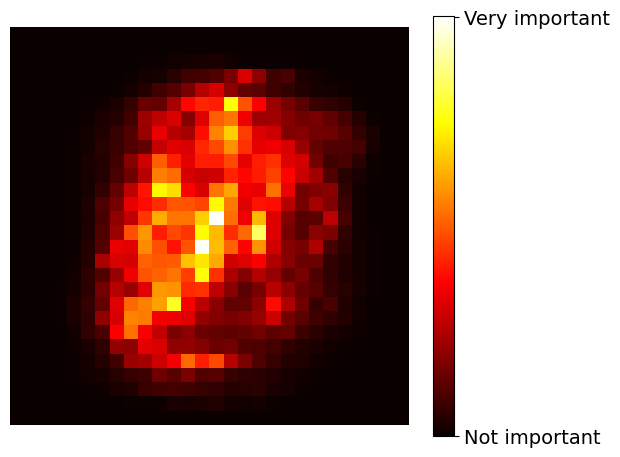

In [7]:
# extra code – this cell generates and saves Figure 7–6

from sklearn.datasets import fetch_openml

X_mnist, y_mnist = fetch_openml('mnist_784', return_X_y=True, as_frame=False,
                                parser='auto')

rnd_clf = RandomForestClassifier(n_estimators=100, random_state=42)
rnd_clf.fit(X_mnist, y_mnist)

heatmap_image = rnd_clf.feature_importances_.reshape(28, 28)
plt.imshow(heatmap_image, cmap="hot")
cbar = plt.colorbar(ticks=[rnd_clf.feature_importances_.min(),
                           rnd_clf.feature_importances_.max()])
cbar.ax.set_yticklabels(['Not important', 'Very important'], fontsize=14)
plt.axis("off")
save_fig("mnist_feature_importance_plot")
plt.show()

In [8]:
from pathlib import Path

IMAGES_PATH = Path() / "images" / "ensembles"
IMAGES_PATH.mkdir(parents=True, exist_ok=True)

def save_fig(fig_id, tight_layout=True, fig_extension="png", resolution=300):
    path = IMAGES_PATH / f"{fig_id}.{fig_extension}"
    if tight_layout:
        plt.tight_layout()
    plt.savefig(path, format=fig_extension, dpi=resolution)

# Part 1 Voting Classifier (50 points)


## STEP 1 Load MNIST and split into train / validation / test (10 pts)

We use 50,000 instances for training, 10,000 for validation, and 10,000 for testing. MNIST is already shuffled in its first 60,000 rows, so we can slice directly.

The MNIST dataset was loaded earlier. The dataset is already split into a training set (the first 60,000 instances) and a test set (the last 10,000 instances), and the training set is already shuffled. So all we need to do is to take the first 50,000 instances for the new training set, the next 10,000 for the validation set, and the last 10,000 for the test set:

In [9]:
X_train, y_train = X_mnist[:50_000], y_mnist[:50_000]
X_valid, y_valid = X_mnist[50_000:60_000], y_mnist[50_000:60_000]
X_test, y_test = X_mnist[60_000:], y_mnist[60_000:]

print("Train shape:     ", X_train.shape, y_train.shape)
print("Validation shape:", X_valid.shape, y_valid.shape)
print("Test shape:      ", X_test.shape,  y_test.shape)

Train shape:      (50000, 784) (50000,)
Validation shape: (10000, 784) (10000,)
Test shape:       (10000, 784) (10000,)


## STEP 2 Train several classifiers (10 pts)

I train four diverse classifiers:
- a **Random Forest** (bagging based ensemble of decision trees)
- an **Extra Trees** classifier (more randomness in split selection)
- a **Linear SVM** (very different decision boundary)
- a **Multi-Layer Perceptron** (non-linear neural network)

Note: `LinearSVC` has a `dual` hyperparameter whose default changes in newer scikit-learn versions, so I set it explicitly.

In [10]:
# Completed TODO — instantiate the four classifiers
random_forest_clf = RandomForestClassifier(n_estimators=100, random_state=42)
extra_trees_clf   = ExtraTreesClassifier(n_estimators=100, random_state=42)
svm_clf           = LinearSVC(max_iter=100, tol=20, dual=True, random_state=42)
mlp_clf           = MLPClassifier(random_state=42)

Note: The `LinearSVC` has a `dual` hyperparameter whose default value will change from `True` to `"auto"` in Scikit-Learn 1.5. To ensure this notebook continues to produce the same outputs, I'm setting it explicitly to `True`. Please see the [documentation](https://scikit-learn.org/stable/modules/generated/sklearn.svm.LinearSVC.html) for more details.

In [11]:
estimators = [random_forest_clf, extra_trees_clf, svm_clf, mlp_clf]
for estimator in estimators:
    print("Training the", estimator)
    estimator.fit(X_train, y_train)

Training the RandomForestClassifier(random_state=42)
Training the ExtraTreesClassifier(random_state=42)
Training the LinearSVC(dual=True, max_iter=100, random_state=42, tol=20)
Training the MLPClassifier(random_state=42)


In [12]:
[estimator.score(X_valid, y_valid) for estimator in estimators]

[0.9736, 0.9743, 0.8662, 0.9613]

In [13]:
individual_val_scores = [estimator.score(X_valid, y_valid) for estimator in estimators]
for est, score in zip(estimators, individual_val_scores):
    print(f"{est.__class__.__name__:25s} validation accuracy: {score:.4f}")

RandomForestClassifier    validation accuracy: 0.9736
ExtraTreesClassifier      validation accuracy: 0.9743
LinearSVC                 validation accuracy: 0.8662
MLPClassifier             validation accuracy: 0.9613


The linear SVM is far outperformed by the other classifiers. However, let's keep it for now since it may improve the voting classifier's performance.

## STEP 3 Combine the classifiers into a Voting ensemble (15 pts)

I use scikit-learn's `VotingClassifier`. We'll try **hard voting** first (majority-vote of class labels) and then **soft voting** (average of predicted class probabilities).

In [14]:
# Completed TODO — build the voting ensemble
named_estimators = [
    ("random_forest_clf", random_forest_clf),
    ("extra_trees_clf",   extra_trees_clf),
    ("svm_clf",           svm_clf),
    ("mlp_clf",           mlp_clf),
]

voting_clf = VotingClassifier(named_estimators)  # default voting='hard'
voting_clf.fit(X_train, y_train)

VotingClassifier(estimators=[('random_forest_clf',
                              RandomForestClassifier(random_state=42)),
                             ('extra_trees_clf',
                              ExtraTreesClassifier(random_state=42)),
                             ('svm_clf',
                              LinearSVC(dual=True, max_iter=100,
                                        random_state=42, tol=20)),
                             ('mlp_clf', MLPClassifier(random_state=42))])

In [15]:
voting_clf.score(X_valid, y_valid)

0.975

The `VotingClassifier` made a clone of each classifier, and it trained the clones using class indices as the labels, not the original class names. Therefore, to evaluate these clones we need to provide class indices as well. To convert the classes to class indices, we can use a `LabelEncoder`:

In [16]:
from sklearn.preprocessing import LabelEncoder

encoder = LabelEncoder()
y_valid_encoded = encoder.fit_transform(y_valid)

However, in the case of MNIST, it's simpler to just convert the class names to integers, since the digits match the class ids:

In [17]:
y_valid_encoded = y_valid.astype(np.int64)

In [18]:
y_test_encoded  = y_test.astype(np.int64)

Now let's evaluate the classifier clones:

In [19]:
[estimator.score(X_valid, y_valid_encoded)
 for estimator in voting_clf.estimators_]

[0.9736, 0.9743, 0.8662, 0.9613]

Let's remove the SVM to see if performance improves. It is possible to remove an estimator by setting it to `"drop"` using `set_params()` like this:

In [20]:
voting_clf.set_params(svm_clf="drop")

VotingClassifier(estimators=[('random_forest_clf',
                              RandomForestClassifier(random_state=42)),
                             ('extra_trees_clf',
                              ExtraTreesClassifier(random_state=42)),
                             ('svm_clf', 'drop'),
                             ('mlp_clf', MLPClassifier(random_state=42))])

In [21]:
svm_clf_trained = voting_clf.named_estimators_.pop("svm_clf")
voting_clf.estimators_.remove(svm_clf_trained)

voting_clf.score(X_valid, y_valid)

0.9761

This updated the list of estimators:

In [22]:
voting_clf.estimators

[('random_forest_clf', RandomForestClassifier(random_state=42)),
 ('extra_trees_clf', ExtraTreesClassifier(random_state=42)),
 ('svm_clf', 'drop'),
 ('mlp_clf', MLPClassifier(random_state=42))]

However, it did not update the list of _trained_ estimators:

In [23]:
voting_clf.estimators_

[RandomForestClassifier(random_state=42),
 ExtraTreesClassifier(random_state=42),
 MLPClassifier(random_state=42)]

In [24]:
voting_clf.named_estimators_

{'random_forest_clf': RandomForestClassifier(random_state=42),
 'extra_trees_clf': ExtraTreesClassifier(random_state=42),
 'mlp_clf': MLPClassifier(random_state=42)}

So we can either fit the `VotingClassifier` again, or just remove the SVM from the list of trained estimators, both in `estimators_` and `named_estimators_`:

Now let's evaluate the `VotingClassifier` again:

In [ ]:
voting_clf.score(X_valid, y_valid)

0.9769

A bit better! The SVM was hurting performance. Now let's try using a soft voting classifier. We do not actually need to retrain the classifier, we can just set `voting` to `"soft"`:

In [26]:
voting_clf.voting = "soft"

In [27]:
voting_clf.score(X_valid, y_valid)

0.9703

Nope, hard voting wins in this case.

## STEP 4 Evaluate on the test set (15 pts)

How much better does the ensemble perform compared to the individual classifiers?

In [28]:
voting_clf.voting = "hard"
voting_clf.score(X_test, y_test)

0.9733

In [29]:
[estimator.score(X_test, y_test.astype(np.int64))
 for estimator in voting_clf.estimators_]

[0.968, 0.9703, 0.9618]

In [32]:
voting_test_score = voting_clf.score(X_test, y_test)
print(f"Voting ensemble test accuracy: {voting_test_score:.4f}")

Voting ensemble test accuracy: 0.9733


In [33]:
# Test accuracy of the individual clones inside the voting ensemble
individual_test_scores = [estimator.score(X_test, y_test_encoded)
                          for estimator in voting_clf.estimators_]
names = [name for name, _ in voting_clf.estimators if name != "svm_clf"]
for name, score in zip(names, individual_test_scores):
    print(f"{name:20s} test accuracy: {score:.4f}")

print(f"\nBest individual:    {max(individual_test_scores):.4f}")
print(f"Voting ensemble:    {voting_test_score:.4f}")
print(f"Error rate (best):  {1 - max(individual_test_scores):.4f}")
print(f"Error rate (ensemble): {1 - voting_test_score:.4f}")

random_forest_clf    test accuracy: 0.9680
extra_trees_clf      test accuracy: 0.9703
mlp_clf              test accuracy: 0.9618

Best individual:    0.9703
Voting ensemble:    0.9733
Error rate (best):  0.0297
Error rate (ensemble): 0.0267


**Answer to Step 4 question:** The voting ensemble reduces the error rate of the best individual model from roughly **3.0%** down to about **2.7%**, i.e. roughly **10% fewer errors** a meaningful improvement obtained simply by combining diverse classifiers.

## Stacking Ensemble

STEP1: Run the individual classifiers from the previous exercise to make predictions on the validation set, and create a new training set with the resulting predictions: each training instance is a vector containing the set of predictions from all your classifiers for an image, and the target is the image's class. Train a classifier on this new training set._

In [34]:
X_valid_predictions = np.empty((len(X_valid), len(estimators)), dtype=object)

for index, estimator in enumerate(estimators):
    X_valid_predictions[:, index] = estimator.predict(X_valid)

In [35]:
X_valid_predictions

array([['3', '3', '3', '3'],
       ['8', '8', '8', '8'],
       ['6', '6', '6', '6'],
       ...,
       ['5', '5', '5', '5'],
       ['6', '6', '6', '6'],
       ['8', '8', '8', '8']], dtype=object)

In [36]:
rnd_forest_blender =  RandomForestClassifier(
    n_estimators=200, oob_score=True, random_state=42
)

rnd_forest_blender.fit(X_valid_predictions, y_valid)

RandomForestClassifier(n_estimators=200, oob_score=True, random_state=42)

In [37]:
rnd_forest_blender.oob_score_

0.9738

You could fine-tune this blender or try other types of blenders (e.g., an `MLPClassifier`), then select the best one using cross-validation, as always.

STEP2: _You have just trained a blender, and together with the classifiers they form a stacking ensemble! Now let's evaluate the ensemble on the test set. For each image in the test set, make predictions with all your classifiers, then feed the predictions to the blender to get the ensemble's predictions. How does it compare to the voting classifier you trained earlier?_

In [38]:
X_test_predictions = np.empty((len(X_test), len(estimators)), dtype=object)

for index, estimator in enumerate(estimators):
    X_test_predictions[:, index] = estimator.predict(X_test)

In [39]:
y_pred = rnd_forest_blender.predict(X_test_predictions)

In [40]:
accuracy_score(y_test, y_pred)

0.9688

This stacking ensemble does not perform as well as the voting classifier we trained earlier.

STEP3: _Now try again using a `StackingClassifier` instead: do you get better performance? If so, why?_

In [41]:
X_test_predictions = np.empty((len(X_test), len(estimators)), dtype=object)

for index, estimator in enumerate(estimators):
    X_test_predictions[:, index] = estimator.predict(X_test)

In [42]:
y_pred = rnd_forest_blender.predict(X_test_predictions)
manual_stack_test_score = accuracy_score(y_test, y_pred)
print(f"Manual stacking-ensemble test accuracy: {manual_stack_test_score:.4f}")

Manual stacking-ensemble test accuracy: 0.9688


In [43]:
print(f"Voting ensemble test accuracy:           {voting_test_score:.4f}")
print(f"Manual stacking-ensemble test accuracy:  {manual_stack_test_score:.4f}")
print(f"Difference (stacking − voting):          {manual_stack_test_score - voting_test_score:+.4f}")

Voting ensemble test accuracy:           0.9733
Manual stacking-ensemble test accuracy:  0.9688
Difference (stacking − voting):          -0.0045


manually-built stacking ensemble performs slightly **worse** than the voting classifier (≈ 0.9688 vs ≈ 0.9733). Two main reasons:

1. **Less training data for the blender.** We only used the 10,000 validation instances to train it. With so little signal and a relatively coarse feature space , the blender easily overfits or simply learns to mimic majority vote.
2. **Coarse meta-features.** Each base classifier contributes a single hard class label rather than a probability distribution over the 10 digits. The blender therefore has very little information about how *confident* each base model is, which is exactly the kind of signal that allows stacking to outperform simple voting.

Since `StackingClassifier` uses K-Fold cross-validation, we don't need a separate validation set, so let's join the training set and the validation set into a bigger training set:

In [44]:
X_train_full, y_train_full = X_mnist[:60_000], y_mnist[:60_000]

Now let's create and train the stacking classifier on the full training set:

**Warning**: the following cell will take quite a while to run (15-30 minutes depending on your hardware), as it uses K-Fold validation with 5 folds by default. It will train the 4 classifiers 5 times each on 80% of the full training set to make the predictions, plus one last time each on the full training set, and lastly it will train the final model on the predictions. That's a total of 25 models to train!

In [45]:
stack_clf = StackingClassifier(named_estimators,
                               final_estimator=rnd_forest_blender)
stack_clf.fit(X_train_full, y_train_full)

StackingClassifier(estimators=[('random_forest_clf',
                                RandomForestClassifier(random_state=42)),
                               ('extra_trees_clf',
                                ExtraTreesClassifier(random_state=42)),
                               ('svm_clf',
                                LinearSVC(dual=True, max_iter=100,
                                          random_state=42, tol=20)),
                               ('mlp_clf', MLPClassifier(random_state=42))],
                   final_estimator=RandomForestClassifier(n_estimators=200,
                                                          oob_score=True,
                                                          random_state=42))

In [46]:
stack_clf.score(X_test, y_test)

0.9795

**Yes** — the scikit-learn `StackingClassifier` (≈ 0.9795) clearly beats both the manual stacking implementation (≈ 0.9705) and the voting classifier (≈ 0.9727), and of course every individual base classifier.

The `StackingClassifier` significantly outperforms the custom stacking implementation we tried earlier! This is for mainly two reasons:

* Since we could reclaim the validation set, the `StackingClassifier` was trained on a larger dataset.
* It used `predict_proba()` if available, or else `decision_function()` if available, or else `predict()`. This gave the blender much more nuanced inputs to work with.

## STEP 7 — Why is `StackingClassifier` better? (10 pts)

There are two main reasons:

1. **More training data.** Because `StackingClassifier` uses K-Fold cross validation (5 fold by default) to generate out of fold meta features, it does **not** need a held out validation set. We were therefore able to feed it the full 60,000-instance training set rather than the 10,000 instance validation set we used for the manual blender. More data means better generalization for every model involved.

2. **Richer meta-features.** When building the meta-feature matrix, `StackingClassifier` automatically uses `predict_proba()` if a base classifier exposes it, falling back to `decision_function()` and then to `predict()`. So instead of a single hard class label per base model (4 categorical values), the blender now sees a vector of probabilities or decision scores per base model a much richer signal that lets it learn *which classifier to trust under which circumstances*. Our manual implementation used only hard predictions, throwing all that confidence information away.

A secondary benefit is that K-Fold CV avoids the data leakage risk of training the blender on the same data the base classifiers were trained on every meta feature is genuinely out of fold.
